In [1]:
import sys
import json
import astropy.units as u
import gammapy
import matplotlib.pylab as plt
import numpy as np
import pyximport
import seaborn as sns
import yaml
from gammapy.datasets import FluxPointsDataset
from gammapy.estimators import FluxPoints
from gammapy.modeling import Parameter, Parameters
from gammapy.modeling.models import FoVBackgroundModel, Models
from matplotlib import rc
from scipy.interpolate import interp2d
from gammapy.estimators.map.core import DEFAULT_UNIT, FluxMaps
from gammapy.modeling.models.spectral import scale_plot_flux
# import random
sys.path.append("/home/katrin/Documents/nuisance_summary/")
sys.path.append("../")
import Dataset_load  # noqa: E402
from Dataset_Creation import sys_dataset  # noqa: E402

print(f"loaded gammapy version: {gammapy.__version__} ")
print("Supposed to be 1.0 (21-12-2022)")
rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
rc("text", usetex=True)
pyximport.install()

loaded gammapy version: 0.1.dev20025+g3b82a43.d20230724 
Supposed to be 1.0 (21-12-2022)


(None, <pyximport._pyximport3.PyxImportMetaFinder at 0x7f8c437cfdf0>)

In [2]:
savefig = 1
picformat = "png"


## Methods


### Results

In [8]:
infos = np.loadtxt("data/7aP_P_draw_info.txt")

lem = len(infos)
N_max = 1002
N = np.min([lem, N_max])

print(N)
shift_rnds = infos[:N_max, 0]
index_rnds = infos[:N_max, 1]
stat_sums = infos[:N_max, 2]




1002


## RND Likelihood Contours

In [9]:
def read(name):
    with open(name) as data_file:
        data_loaded = json.load(data_file)
    return data_loaded

In [10]:
cs = []
cNs = []
for shift_rnd, tilt_rnd in zip (shift_rnds, index_rnds):
    try:
        c  = read( f'data/contours/6P_068_{shift_rnd:.6}_{tilt_rnd:.6}.json')
        c_N  = read( f'data/contours/6P_068_N_{shift_rnd:.6}_{tilt_rnd:.6}.json')
        cs.append(c)
        cNs.append(c_N)
    except:
        print("not found for:", shift_rnd, tilt_rnd)

not found for: 0.03256438533491521 -0.01740655604868185
not found for: -0.002762728929385906 -0.023606239342489756


In [11]:
from scipy.interpolate import interp1d
def interpolate(cc):
    points = np.column_stack((cc['x'], cc['y']))  # a (nbre_points x nbre_dim) array
    

    # Linear length along the line:
    distance = np.cumsum( np.sqrt(np.sum( np.diff(points, axis=0)**2, axis=1 )) )
    distance = np.insert(distance, 0, 0)/distance[-1]

    # Interpolation for different methods:
    interpolations_methods = ['quadratic']
    alpha = np.linspace(0, 1, 75)

    interpolated_points = {}
    for method in interpolations_methods:
        interpolator =  interp1d(distance, points, kind=method, axis=0)
        interpolated_points[method] = interpolator(alpha)
        
    for method_name, curve in interpolated_points.items():
        c_int = {'x':curve.T[0], 'y': curve.T[1]}
    return c_int

import matplotlib.path as mpltPath
def containing_input(cc):
    path = mpltPath.Path(np.column_stack((cc['x'], cc['y'])))
    mask = path.contains_points(points = ([(2.3, 1.)]))
    return mask[0]



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Wihtout nuis. para: 22.1 % contain input (n = 1000)
With    nuis. para: 65.3 % contain input (n = 1000)


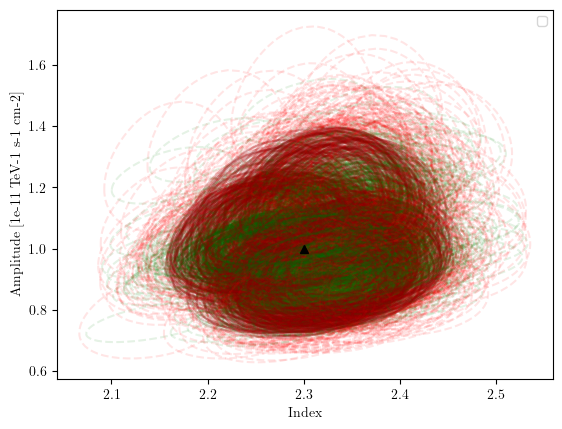

In [12]:
i = -1
containing = 0
containing_N = 0
for c, c_N  in zip(cs[:i], cNs[:i]):
    #plt.plot(c_N['x'], np.array(c_N['y']), label='', color = color+'red', marker = 'o', alpha = alpha)
    
    c = interpolate(c)
    c_N = interpolate(c_N)
    
    contains = containing_input(c)
    contains_N = containing_input(c_N)
    
    if contains: 
        containing += 1
        color = 'dark' ; fmt = '-'; alpha = 0.2
    else:
        color = '' ; fmt = '--'; alpha = 0.1
    plt.plot(c['x'], np.array(c['y']), label='', color = color+'green', linestyle = fmt, alpha = alpha)
    if contains_N: 
        color = 'dark' ; fmt = '-'; alpha = 0.2
        containing_N += 1
        
    else:
        color = '' ; fmt = '--'; alpha = 0.1
    plt.plot(c_N['x'], np.array(c_N['y']), label='', color = color+'red', linestyle = fmt, alpha = alpha)
    
plt.plot(2.3, 1, '^', color = 'black')
plt.legend(fontsize=9, loc='best')

plt.xlabel("Index")
plt.ylabel("Amplitude [1e-11 TeV-1 s-1 cm-2]")
print(f"Wihtout nuis. para: {containing/ len(cs)*100 } % contain input (n = {len(cs)})")
print(f"With    nuis. para: {containing_N/ len(cNs)*100 } % contain input (n = {len(cNs)})")
